# 🌸 Iris Flower Classification
### Machine Learning Classification using Sepal & Petal Measurements

---

**Objective:** Train and evaluate multiple ML models to classify Iris flowers into three species:
- 🌼 *Iris setosa*
- 🌺 *Iris versicolor*
- 🌻 *Iris virginica*

**Features Used:**
| Feature | Description |
|---|---|
| `sepal_length` | Length of the sepal (cm) |
| `sepal_width` | Width of the sepal (cm) |
| `petal_length` | Length of the petal (cm) |
| `petal_width` | Width of the petal (cm) |

---

## 📦 Step 1: Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# Style
sns.set_theme(style='whitegrid', palette='pastel')
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load & Explore the Dataset

In [2]:
# ── Upload your CSV file in Colab using the cell below ──
from google.colab import files
uploaded = files.upload()   # select IRIS.csv when prompted
df = pd.read_csv(list(uploaded.keys())[0])



# Standardise the species column name
if 'species' not in df.columns:
    df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Saving IRIS.csv to IRIS.csv
Dataset shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
# Basic info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(df['species'].value_counts())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

MISSING VALUES
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

CLASS DISTRIBUTION
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [4]:
# Statistical summary
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 📊 Step 3: Exploratory Data Analysis (EDA)

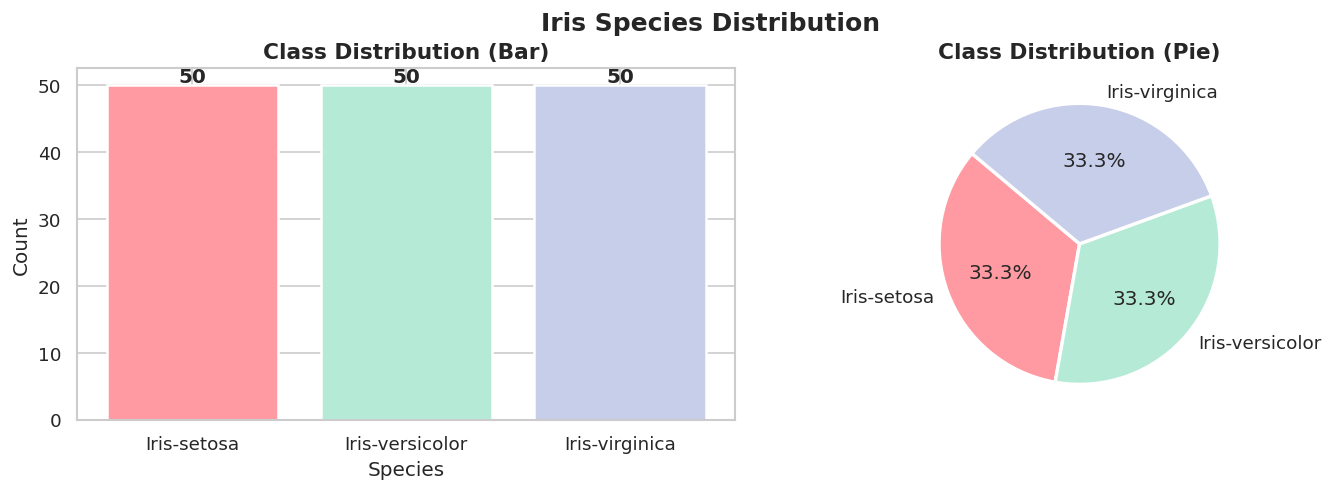

In [5]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['species'].value_counts()
colors = ['#FF9AA2', '#B5EAD7', '#C7CEEA']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Iris Species Distribution', y=1.02, fontsize=15, fontweight='bold')
plt.show()

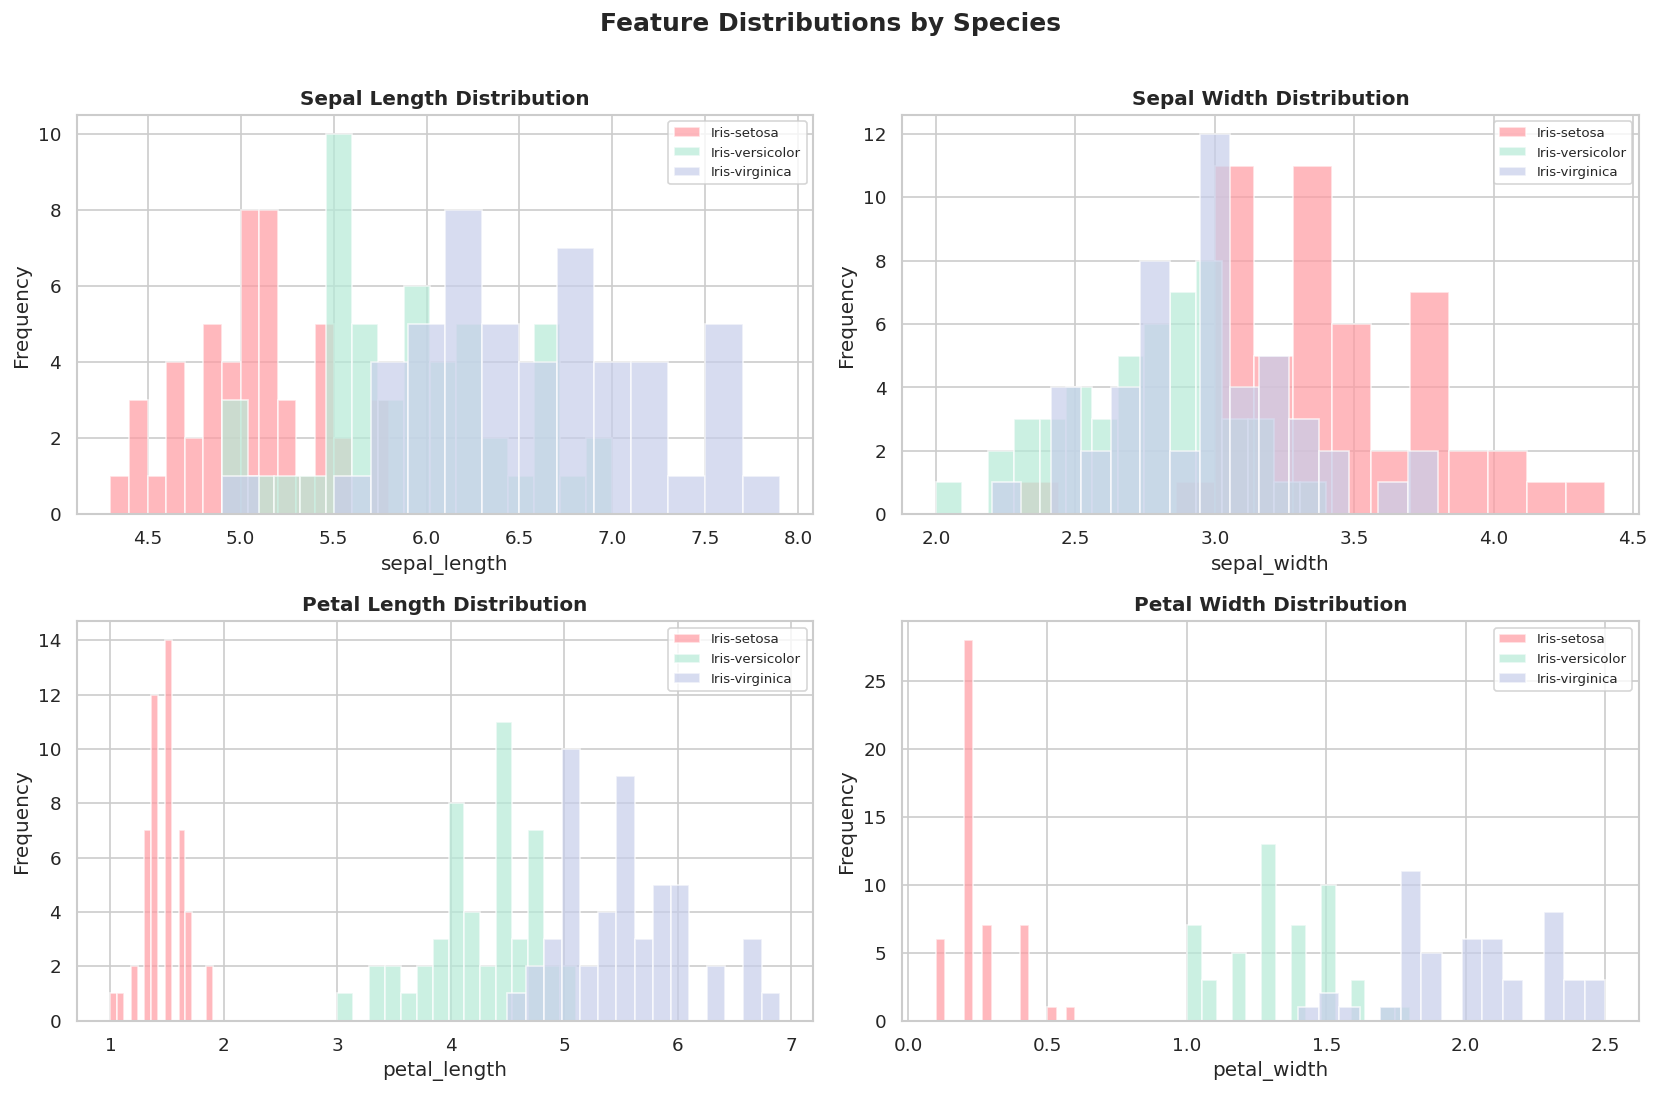

In [6]:
# Feature distributions by species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors_map = {'Iris-setosa': '#FF9AA2', 'Iris-versicolor': '#B5EAD7', 'Iris-virginica': '#C7CEEA'}
# Handle both naming conventions
if 'setosa' in df['species'].values[0]:
    colors_map = {'Iris-setosa': '#FF9AA2', 'Iris-versicolor': '#B5EAD7', 'Iris-virginica': '#C7CEEA'}
else:
    colors_map = {'setosa': '#FF9AA2', 'versicolor': '#B5EAD7', 'virginica': '#C7CEEA'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species, color in colors_map.items():
        subset = df[df['species'] == species][feat]
        axes[i].hist(subset, bins=15, alpha=0.7, color=color, label=species, edgecolor='white')
    axes[i].set_title(f'{feat.replace("_", " ").title()} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

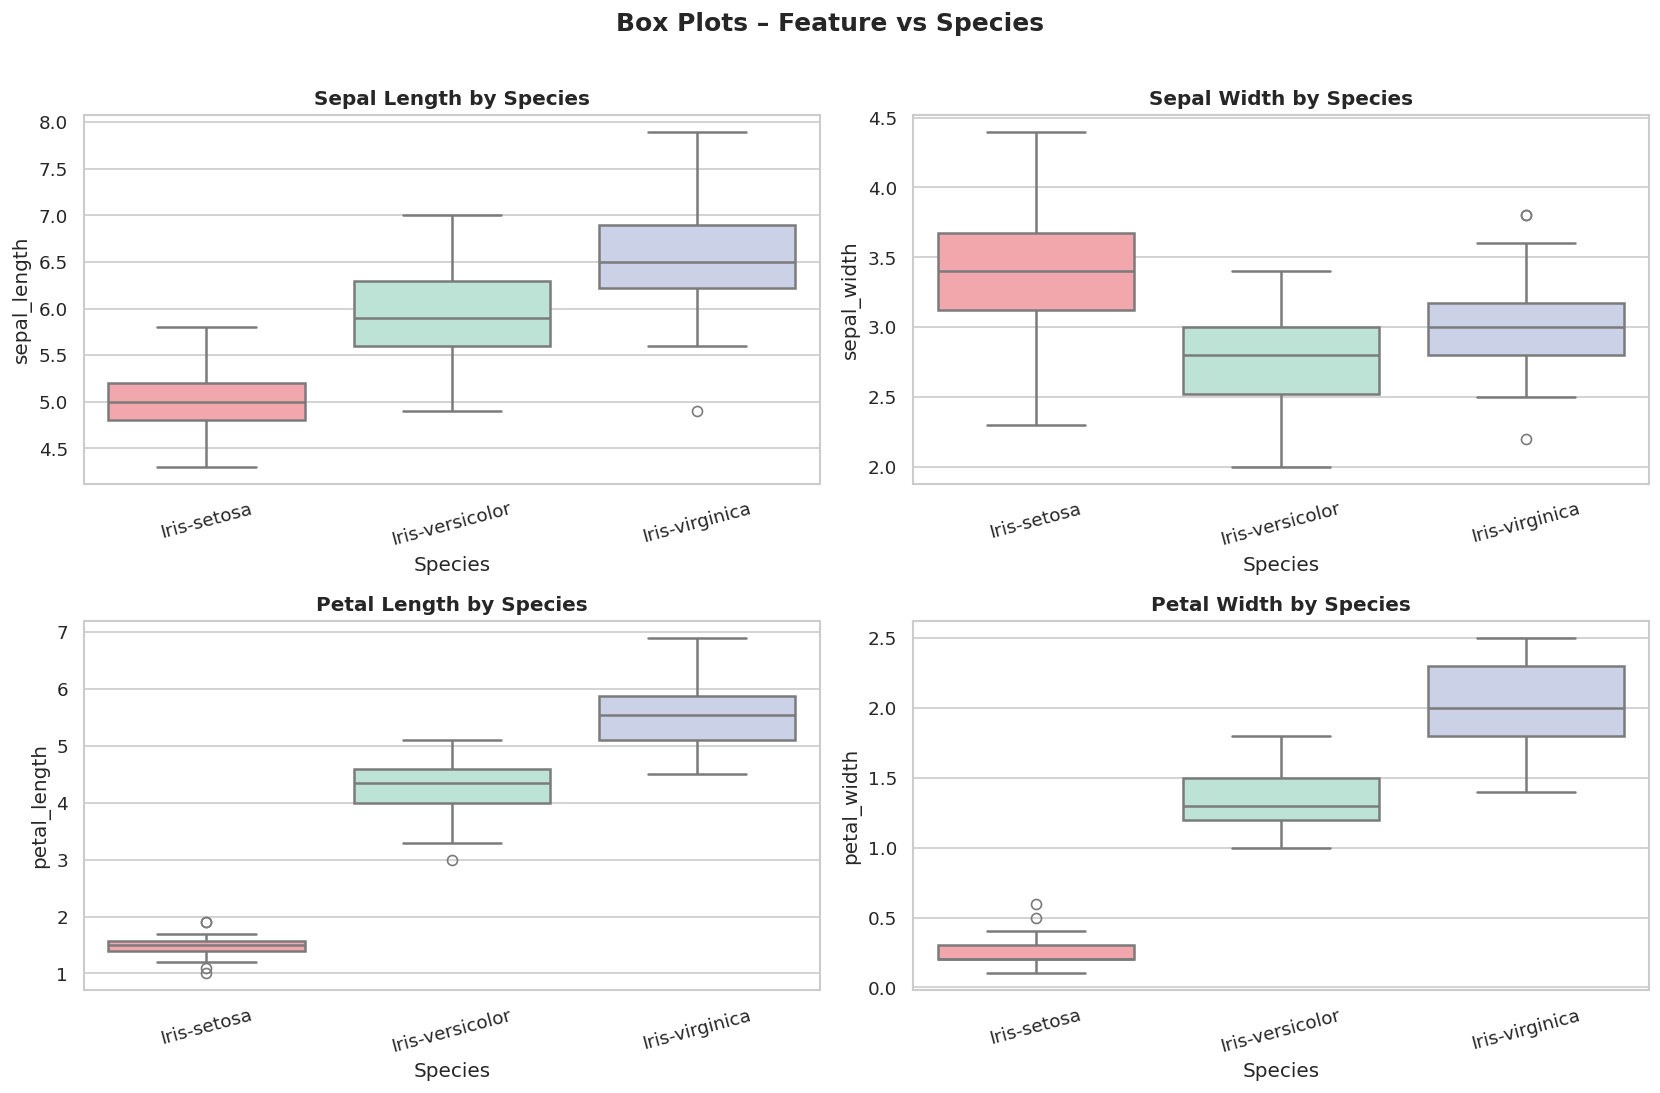

In [7]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(
        data=df, x='species', y=feat, ax=axes[i],
        palette=list(colors_map.values()), linewidth=1.5
    )
    axes[i].set_title(f'{feat.replace("_", " ").title()} by Species', fontweight='bold')
    axes[i].set_xlabel('Species')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Box Plots – Feature vs Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

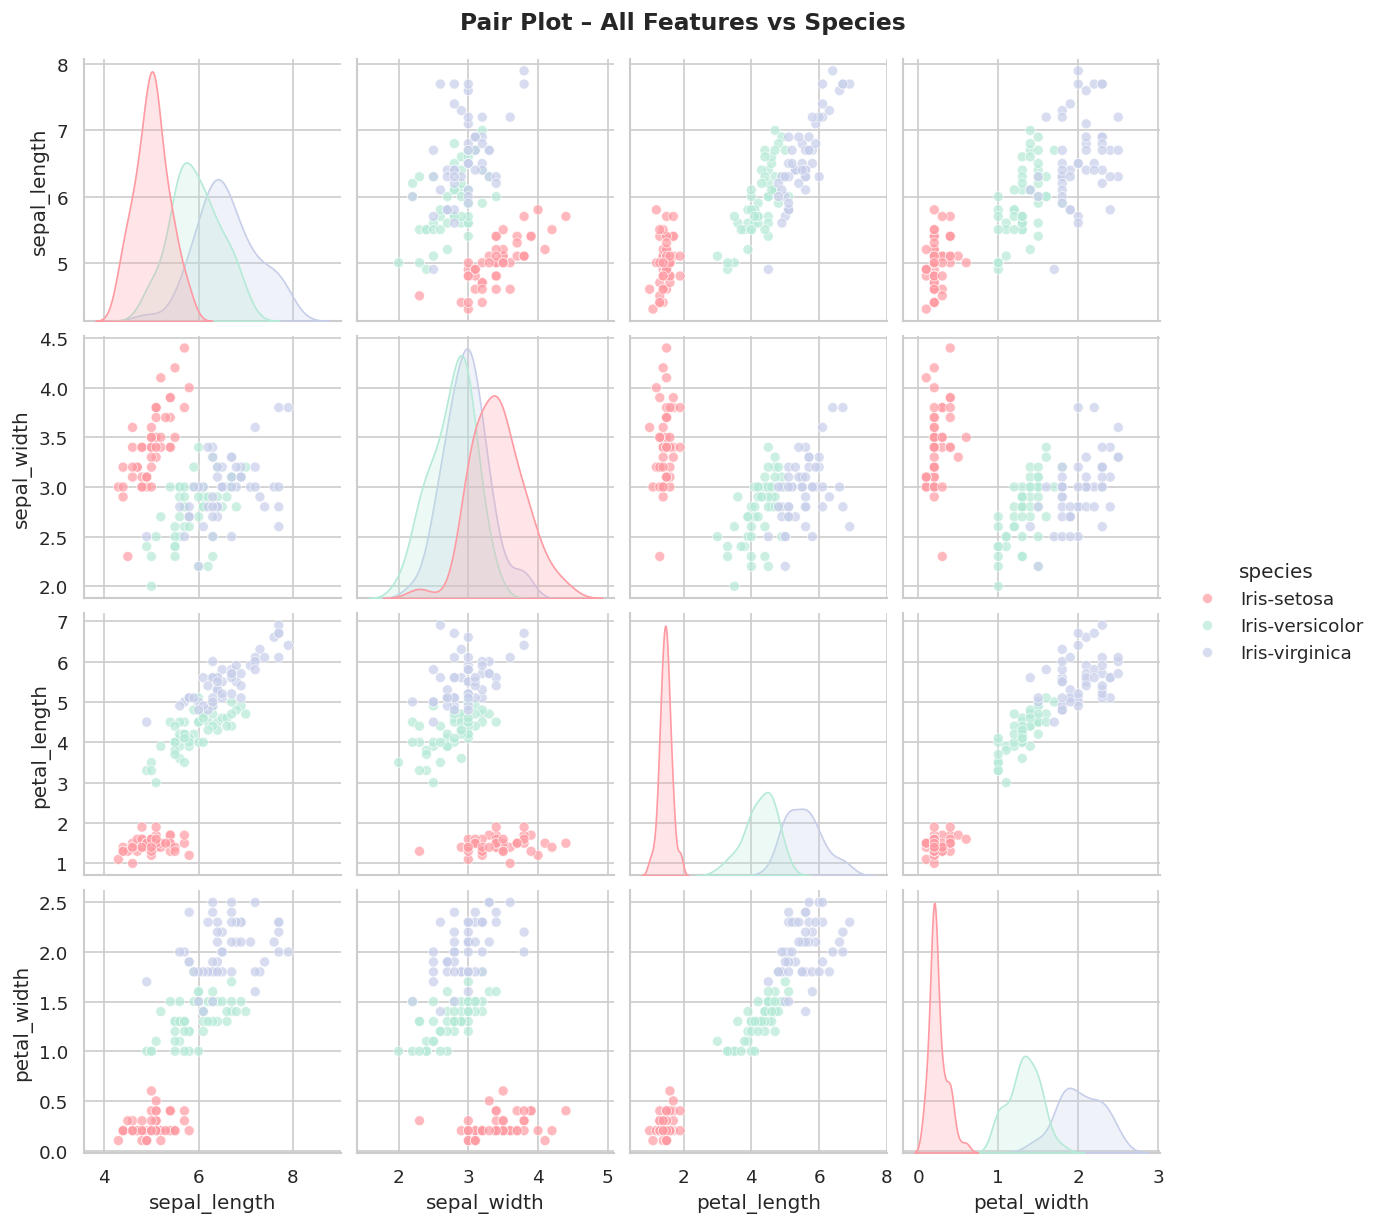

In [8]:
# Pair plot — best single view of separability
sns.pairplot(df, hue='species', palette=list(colors_map.values()),
             plot_kws=dict(alpha=0.7, edgecolor='white'),
             diag_kind='kde')
plt.suptitle('Pair Plot – All Features vs Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()

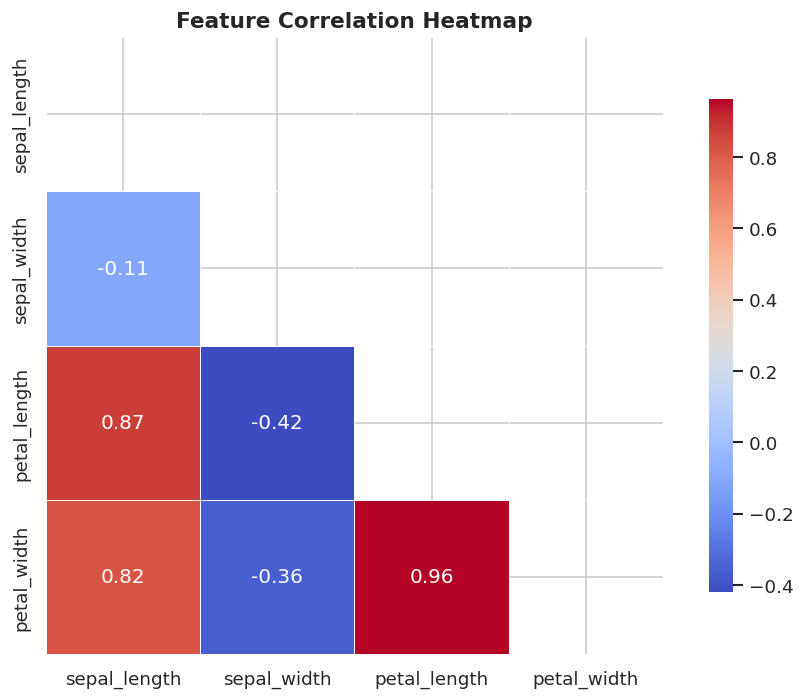

In [9]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

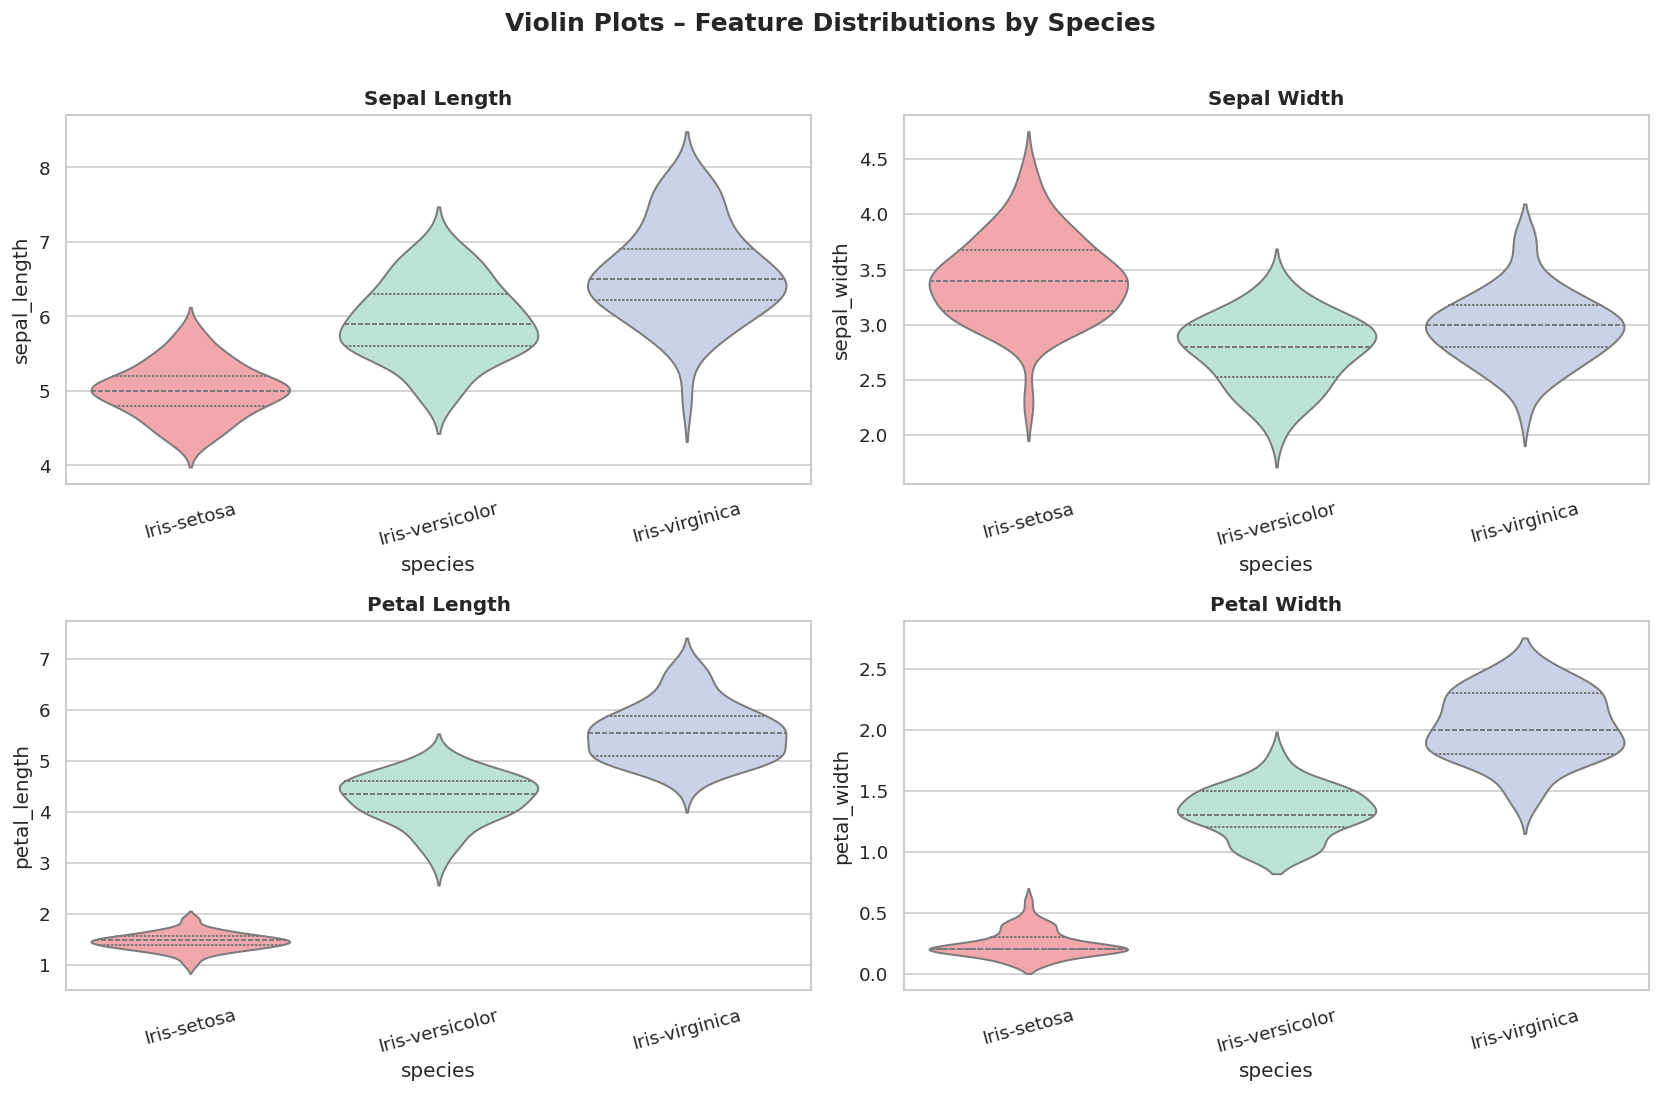

In [10]:
# Violin plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(
        data=df, x='species', y=feat, ax=axes[i],
        palette=list(colors_map.values()), inner='quartile', linewidth=1.2
    )
    axes[i].set_title(f'{feat.replace("_", " ").title()}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Violin Plots – Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Data Preprocessing

In [11]:
# Features and target
X = df[features].values
y_raw = df['species'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  →  {i}")

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Label encoding:
  Iris-setosa  →  0
  Iris-versicolor  →  1
  Iris-virginica  →  2

Training samples : 120
Testing samples  : 30
Features         : 4


## 🤖 Step 5: Train Multiple ML Models

In [12]:
models = {
    'Logistic Regression'      : LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors'      : KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine'   : SVC(kernel='rbf', C=1.0, random_state=42),
    'Decision Tree'            : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'            : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'        : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'              : GaussianNB(),
}

results = {}

print(f"{'Model':<28} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 70)

for name, model in models.items():
    # Scaled data for distance-based models
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc' : test_acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
        'X_test'   : Xte,
    }
    print(f"{name:<28} {train_acc:>10.4f} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}")

Model                         Train Acc   Test Acc    CV Mean   CV Std
----------------------------------------------------------------------
Logistic Regression              0.9583     0.9333     0.9583   0.0264
K-Nearest Neighbors              0.9750     0.9333     0.9667   0.0312
Support Vector Machine           0.9750     0.9667     0.9667   0.0312
Decision Tree                    0.9917     0.9333     0.9417   0.0204
Random Forest                    1.0000     0.9000     0.9500   0.0167
Gradient Boosting                1.0000     0.9667     0.9667   0.0167
Naive Bayes                      0.9583     0.9667     0.9583   0.0264


## 📈 Step 6: Model Comparison

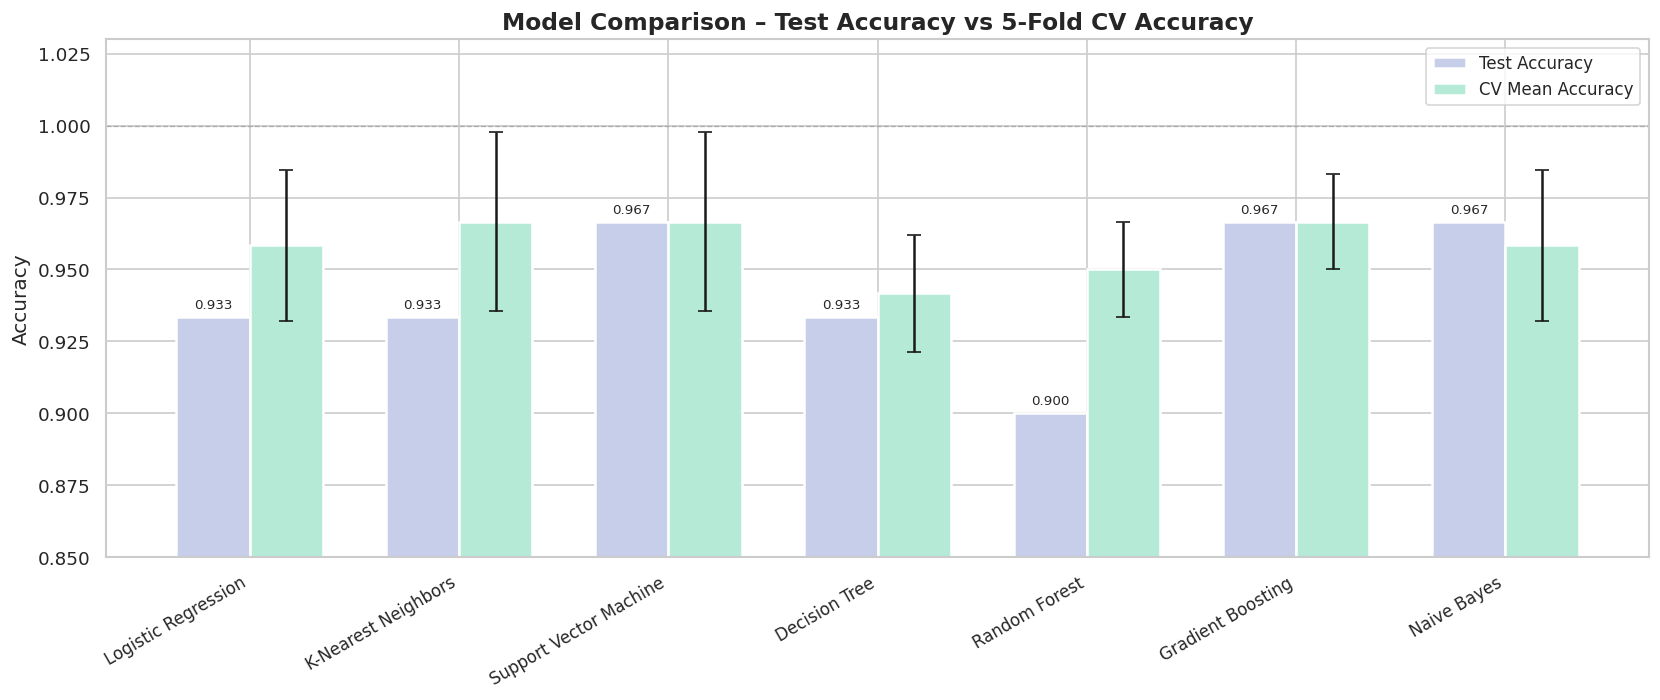

In [13]:
names       = list(results.keys())
test_accs   = [results[n]['test_acc']  for n in names]
cv_means    = [results[n]['cv_mean']   for n in names]
cv_stds     = [results[n]['cv_std']    for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',
               color='#C7CEEA', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, cv_means,  width, label='CV Mean Accuracy',
               color='#B5EAD7', edgecolor='white', linewidth=1.5,
               yerr=cv_stds, capsize=4, error_kw={'elinewidth': 1.5})

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison – Test Accuracy vs 5-Fold CV Accuracy',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 🏆 Step 7: Best Model – Detailed Evaluation

In [14]:
best_name = max(results, key=lambda n: results[n]['cv_mean'])
best      = results[best_name]
best_model = best['model']

print(f"🏆 Best Model : {best_name}")
print(f"   Test Accuracy : {best['test_acc']:.4f}")
print(f"   CV Mean       : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")

y_pred = best_model.predict(best['X_test'])

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

🏆 Best Model : K-Nearest Neighbors
   Test Accuracy : 0.9333
   CV Mean       : 0.9667 ± 0.0312

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



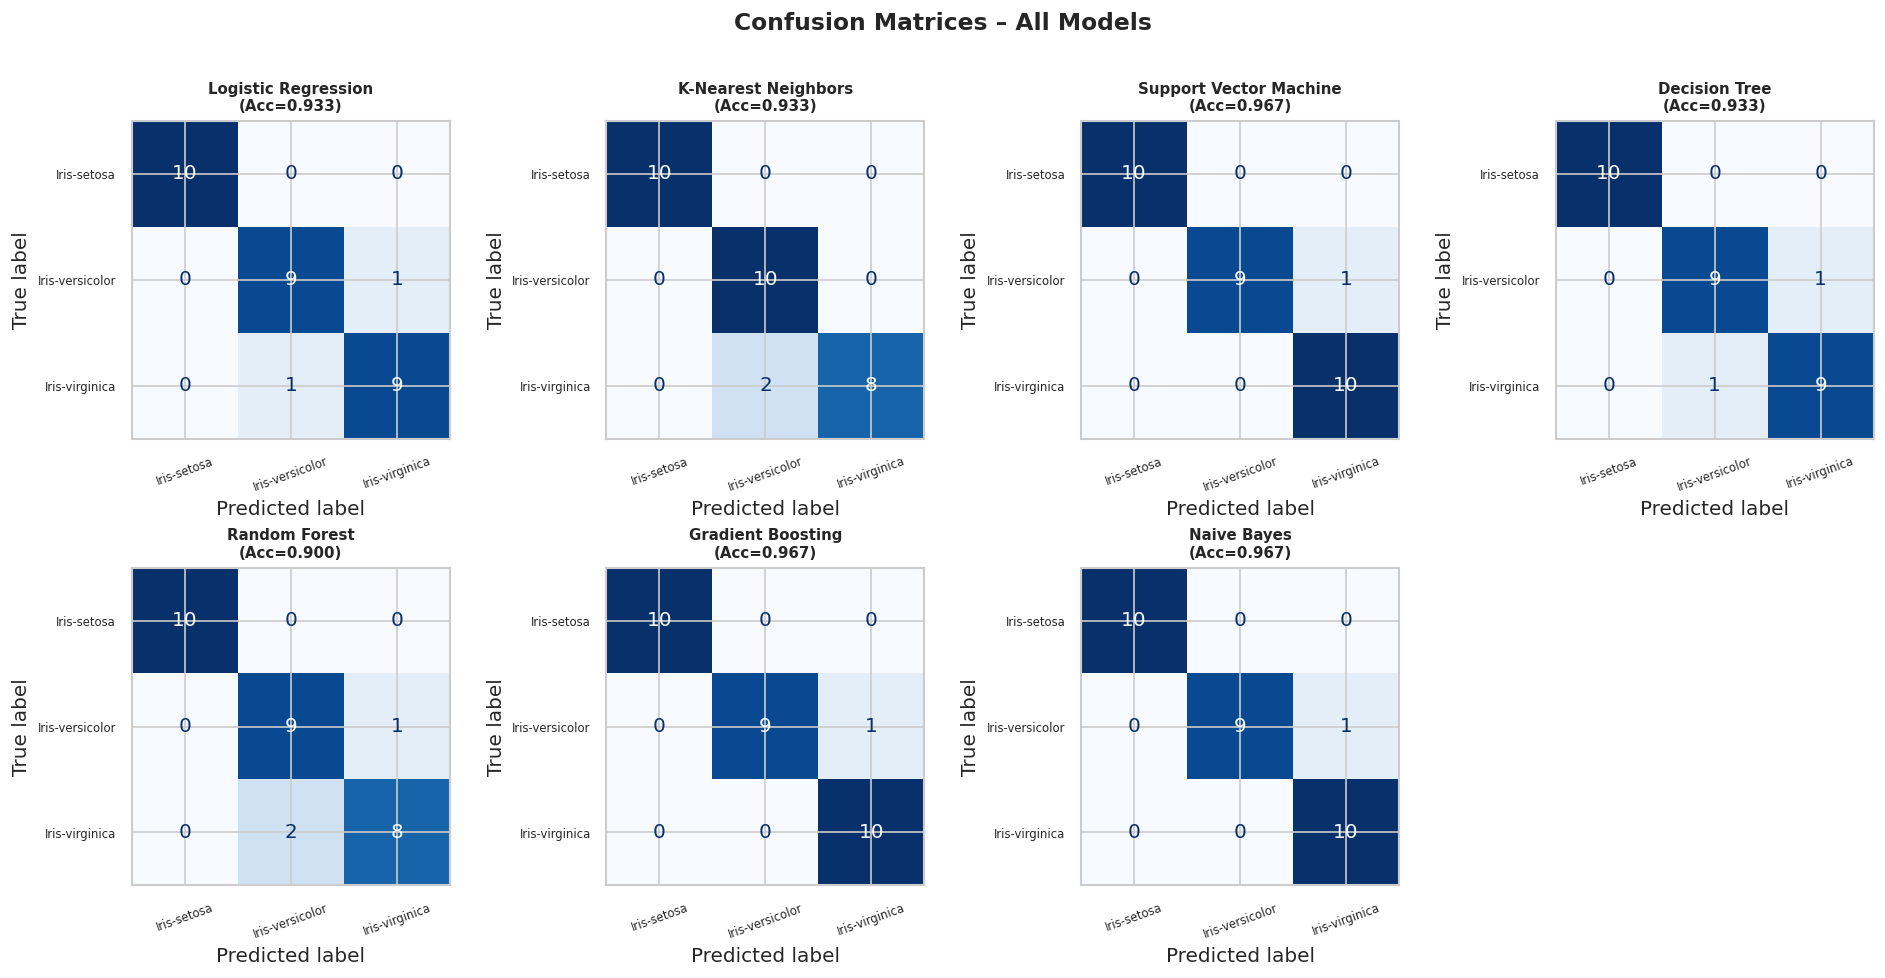

In [15]:
# Confusion matrix – all models
n_models = len(results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    preds = res['model'].predict(res['X_test'])
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}\n(Acc={res['test_acc']:.3f})", fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🌳 Step 8: Decision Tree Visualisation

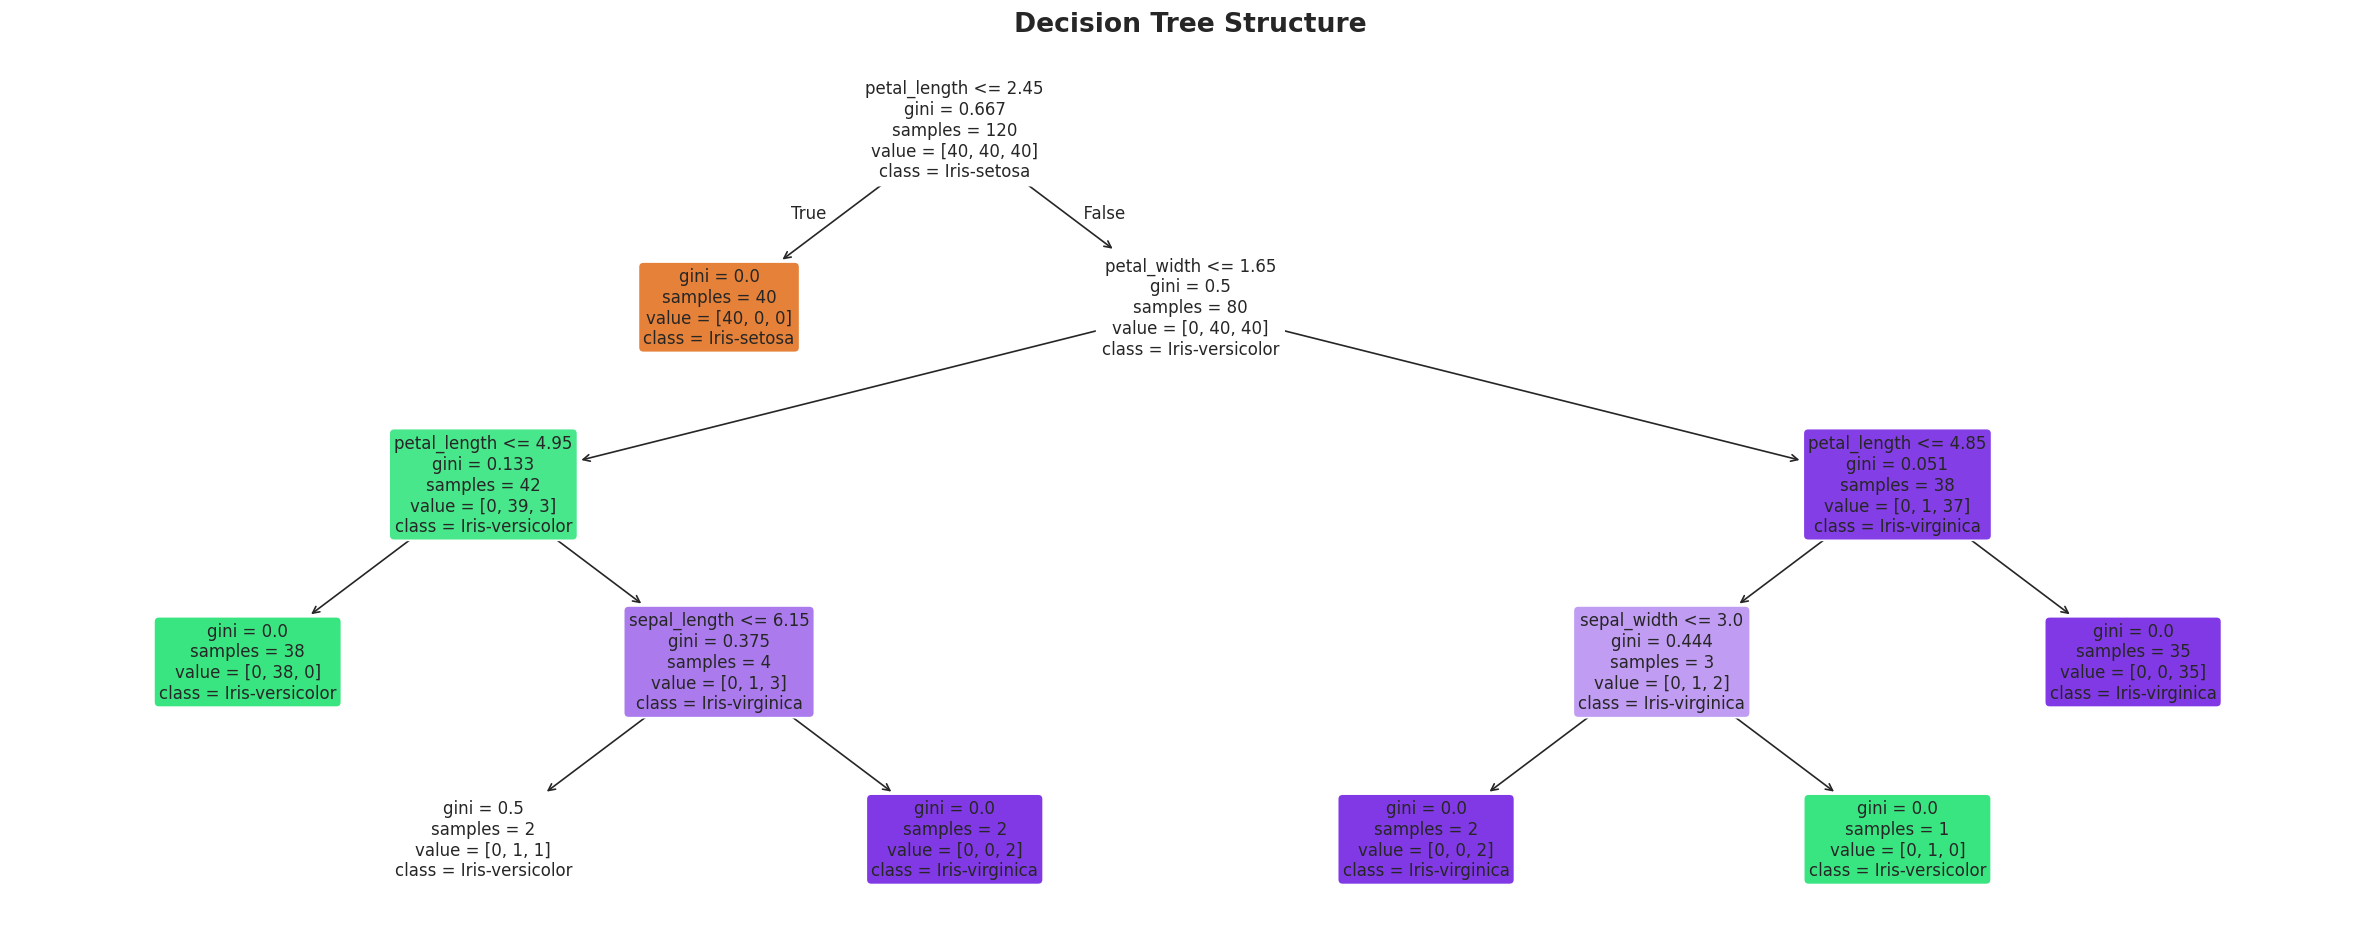

In [16]:
dt = results['Decision Tree']['model']

plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=False
)
plt.title('Decision Tree Structure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 9: Feature Importance (Random Forest)

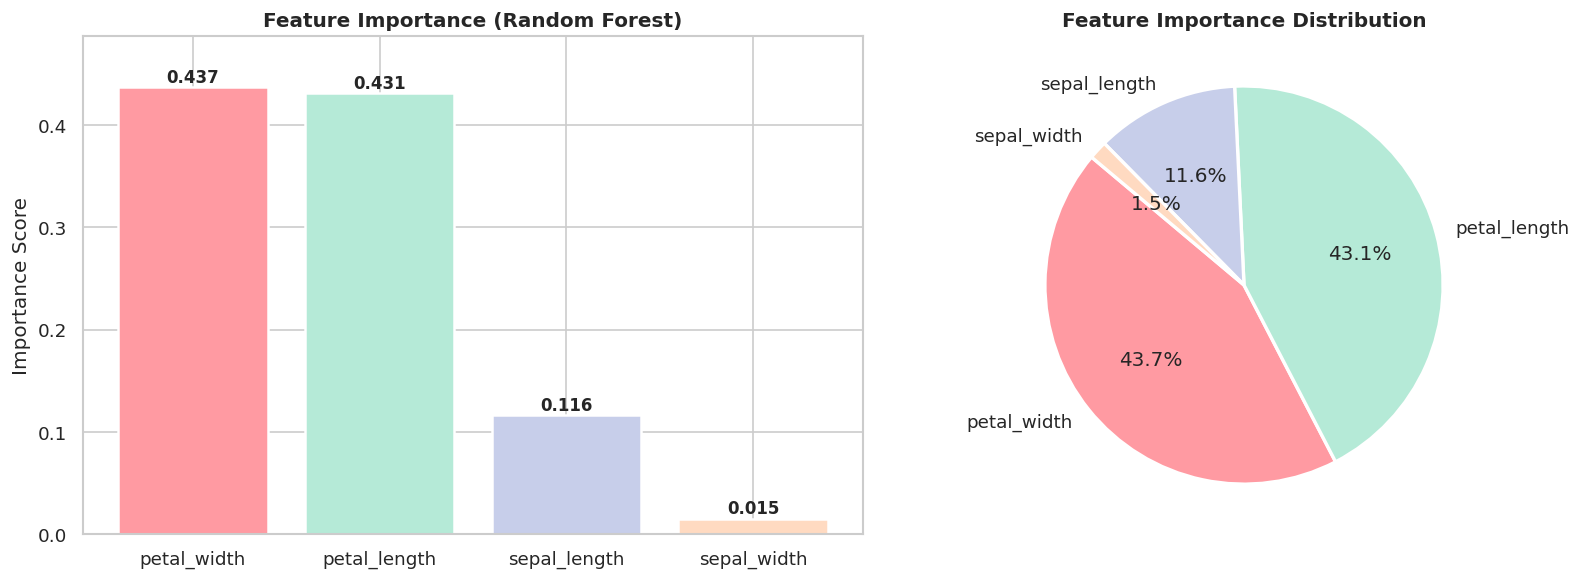

Ranked Features:
  1. petal_width     0.4372
  2. petal_length    0.4315
  3. sepal_length    0.1163
  4. sepal_width     0.0150


In [17]:
rf = results['Random Forest']['model']
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_feat = [features[i] for i in indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(sorted_feat, importances[indices],
                   color=['#FF9AA2','#B5EAD7','#C7CEEA','#FFDAC1'],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].set_ylim(0, max(importances) + 0.05)
for bar, val in zip(bars, importances[indices]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(importances[indices], labels=sorted_feat,
            autopct='%1.1f%%', startangle=140,
            colors=['#FF9AA2','#B5EAD7','#C7CEEA','#FFDAC1'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Feature Importance Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("Ranked Features:")
for rank, (feat, imp) in enumerate(zip(sorted_feat, importances[indices]), 1):
    print(f"  {rank}. {feat:<15} {imp:.4f}")

## 🔧 Step 10: Hyperparameter Tuning (Best Model)

In [18]:
# Tuning Random Forest
param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [None, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
tuned_acc   = accuracy_score(y_test, tuned_model.predict(X_test))
print(f"Tuned Test Accuracy: {tuned_acc:.4f}")

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 0.9583
Tuned Test Accuracy: 0.9667


## 🔍 Step 11: Decision Boundary Visualisation

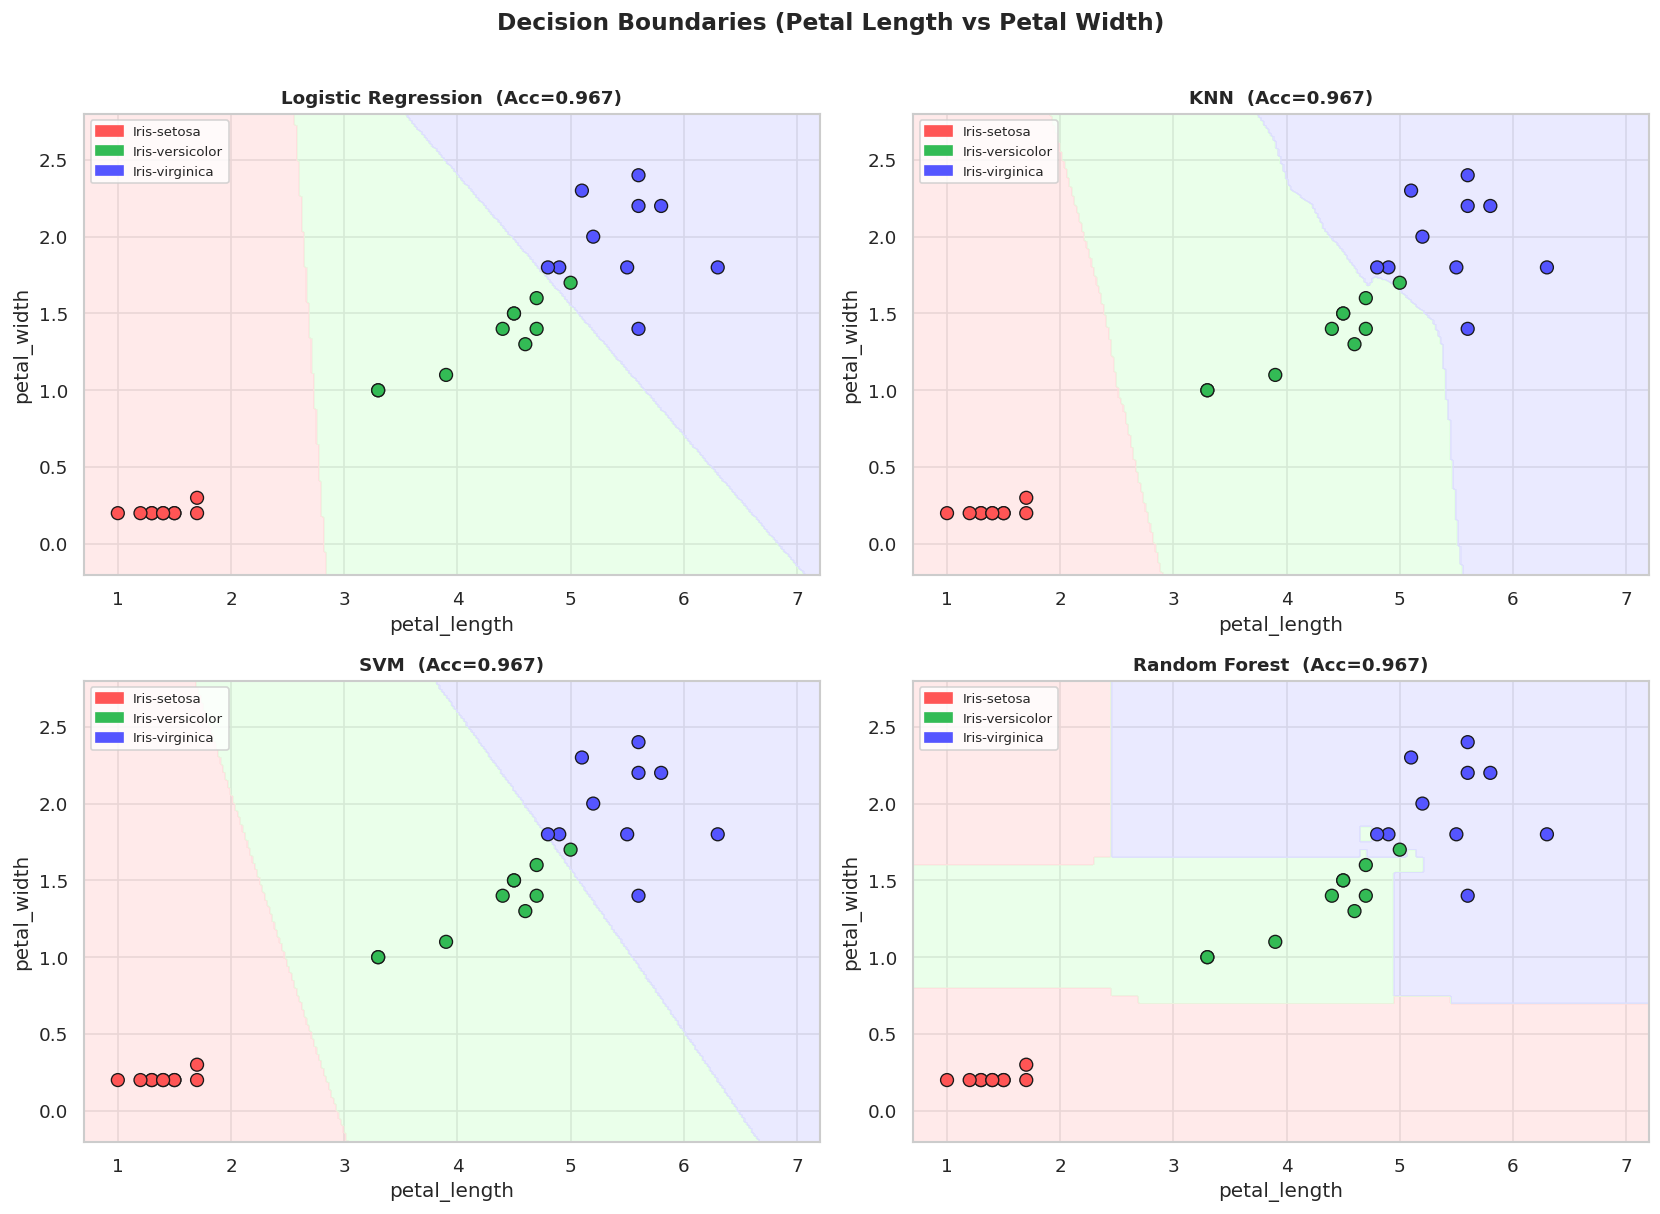

In [19]:
from matplotlib.colors import ListedColormap

# Use only two features for 2D plot: petal_length & petal_width (most discriminative)
feat_idx = [2, 3]   # petal_length, petal_width
feat_labels = [features[i] for i in feat_idx]

X_2d = X[:, feat_idx]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

boundary_models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(kernel='rbf', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
}

cmap_light = ListedColormap(['#FFDDDD', '#DDFFDD', '#DDDDFF'])
cmap_bold  = ListedColormap(['#FF5555', '#33BB55', '#5555FF'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(boundary_models.items()):
    model.fit(X_train_2d, y_train_2d)

    x_min, x_max = X_2d[:, 0].min() - 0.3, X_2d[:, 0].max() + 0.3
    y_min, y_max = X_2d[:, 1].min() - 0.3, X_2d[:, 1].max() + 0.3
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    scatter = axes[idx].scatter(
        X_test_2d[:, 0], X_test_2d[:, 1],
        c=y_test_2d, cmap=cmap_bold, edgecolors='k',
        linewidths=0.8, s=60, zorder=3
    )
    acc = accuracy_score(y_test_2d, model.predict(X_test_2d))
    axes[idx].set_title(f'{name}  (Acc={acc:.3f})', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel(feat_labels[0])
    axes[idx].set_ylabel(feat_labels[1])

    legend_elems = [mpatches.Patch(color=c, label=l)
                    for c, l in zip(['#FF5555','#33BB55','#5555FF'], le.classes_)]
    axes[idx].legend(handles=legend_elems, fontsize=8, loc='upper left')

plt.suptitle('Decision Boundaries (Petal Length vs Petal Width)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🎯 Step 12: Predict on New Data

In [20]:
# Predict species for new/unseen measurements
new_samples = pd.DataFrame({
    'sepal_length': [5.1, 6.5, 7.2],
    'sepal_width' : [3.5, 2.8, 3.0],
    'petal_length': [1.4, 4.6, 5.8],
    'petal_width' : [0.2, 1.5, 2.2],
})

print("Input measurements:")
print(new_samples.to_string(index=False))
print()

for name, res in results.items():
    model = res['model']
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        X_new = scaler.transform(new_samples.values)
    else:
        X_new = new_samples.values

    preds = le.inverse_transform(model.predict(X_new))
    print(f"{name:<28}: {list(preds)}")

Input measurements:
 sepal_length  sepal_width  petal_length  petal_width
          5.1          3.5           1.4          0.2
          6.5          2.8           4.6          1.5
          7.2          3.0           5.8          2.2

Logistic Regression         : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
K-Nearest Neighbors         : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Support Vector Machine      : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Decision Tree               : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Random Forest               : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Gradient Boosting           : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Naive Bayes                 : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 📝 Step 13: Final Summary

In [21]:
print("=" * 60)
print("           IRIS CLASSIFICATION – FINAL SUMMARY")
print("=" * 60)
print(f"{'Model':<28} {'Test Acc':>10} {'CV Mean':>10}")
print("-" * 50)

sorted_results = sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True)
for rank, (name, res) in enumerate(sorted_results, 1):
    flag = "🏆" if rank == 1 else "  "
    print(f"{flag} {name:<26} {res['test_acc']:>10.4f} {res['cv_mean']:>10.4f}")

print("=" * 60)
best_name_final = sorted_results[0][0]
best_res_final  = sorted_results[0][1]
print(f"\n✅ Best model    : {best_name_final}")
print(f"   Test accuracy : {best_res_final['test_acc'] * 100:.2f}%")
print(f"   CV accuracy   : {best_res_final['cv_mean'] * 100:.2f}% ± {best_res_final['cv_std'] * 100:.2f}%")
print("\nKey findings:")
print("  • Petal length & petal width are the most discriminative features")
print("  • Iris setosa is linearly separable from the other two species")
print("  • Versicolor and Virginica show slight overlap in the feature space")
print("  • All models achieve > 93% accuracy on this dataset")

           IRIS CLASSIFICATION – FINAL SUMMARY
Model                          Test Acc    CV Mean
--------------------------------------------------
🏆 K-Nearest Neighbors            0.9333     0.9667
   Support Vector Machine         0.9667     0.9667
   Gradient Boosting              0.9667     0.9667
   Logistic Regression            0.9333     0.9583
   Naive Bayes                    0.9667     0.9583
   Random Forest                  0.9000     0.9500
   Decision Tree                  0.9333     0.9417

✅ Best model    : K-Nearest Neighbors
   Test accuracy : 93.33%
   CV accuracy   : 96.67% ± 3.12%

Key findings:
  • Petal length & petal width are the most discriminative features
  • Iris setosa is linearly separable from the other two species
  • Versicolor and Virginica show slight overlap in the feature space
  • All models achieve > 93% accuracy on this dataset
